In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [2]:
# Load the original dataset
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')

# Separate features and target
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape: ', X_test.shape)
print('\nClass distribution in training:')
print(y_train.value_counts())

Training set shape: (239, 12)
Testing set shape:  (60, 12)

Class distribution in training:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64


In [3]:
# Random Forest does NOT require feature scaling, but we apply it
# here for consistency with the other models in this assignment.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling applied using StandardScaler.')

Feature scaling applied using StandardScaler.


In [4]:
rf_model = RandomForestClassifier(
    n_estimators=100,         # 100 decision trees in the forest
    class_weight='balanced',  # handles class imbalance
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
print('Random Forest model trained.')
print(f'Number of trees: {rf_model.n_estimators}')

Random Forest model trained.
Number of trees: 100


In [5]:
y_pred      = rf_model.predict(X_test_scaled)
y_pred_prob = rf_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (DEATH)

# --- Core Metrics ---
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {accuracy:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

Accuracy : 0.8500


ROC-AUC  : 0.9050

Classification Report:
              precision    recall  f1-score   support

Survived (0)       0.85      0.95      0.90        41
    Died (1)       0.86      0.63      0.73        19

    accuracy                           0.85        60
   macro avg       0.85      0.79      0.81        60
weighted avg       0.85      0.85      0.84        60



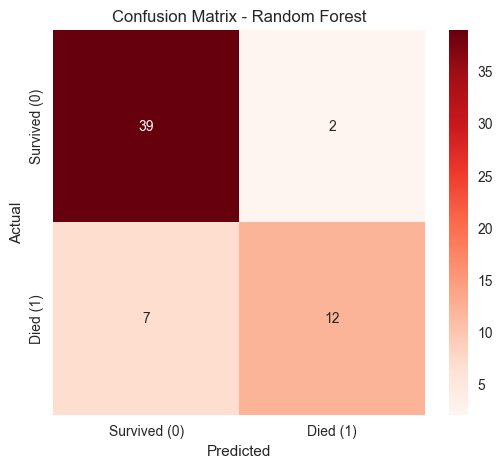

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Survived (0)', 'Died (1)'],
            yticklabels=['Survived (0)', 'Died (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

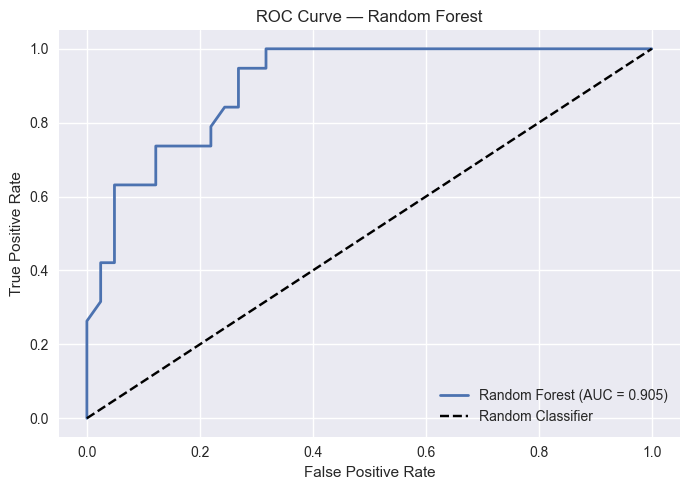

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [8]:
# Use scaled training data for CV
cv_scores_acc = cross_val_score(rf_model, X_train_scaled, y_train,
                                 cv=5, scoring='accuracy')
cv_scores_auc = cross_val_score(rf_model, X_train_scaled, y_train,
                                 cv=5, scoring='roc_auc')

print('5-Fold Cross-Validation Results (on training data):')
print(f'  Accuracy : {cv_scores_acc.mean():.4f} ± {cv_scores_acc.std():.4f}')
print(f'  ROC-AUC  : {cv_scores_auc.mean():.4f} ± {cv_scores_auc.std():.4f}')

5-Fold Cross-Validation Results (on training data):
  Accuracy : 0.8495 ± 0.0442
  ROC-AUC  : 0.9206 ± 0.0478


Feature Importances (sorted by magnitude):
                 Feature  Importance
                    time    0.376176
        serum_creatinine    0.160101
       ejection_fraction    0.122045
creatinine_phosphokinase    0.076633
                     age    0.070440
               platelets    0.069498
            serum_sodium    0.066868
                 anaemia    0.013251
                diabetes    0.012284
                 smoking    0.011588
     high_blood_pressure    0.011215
                     sex    0.009902


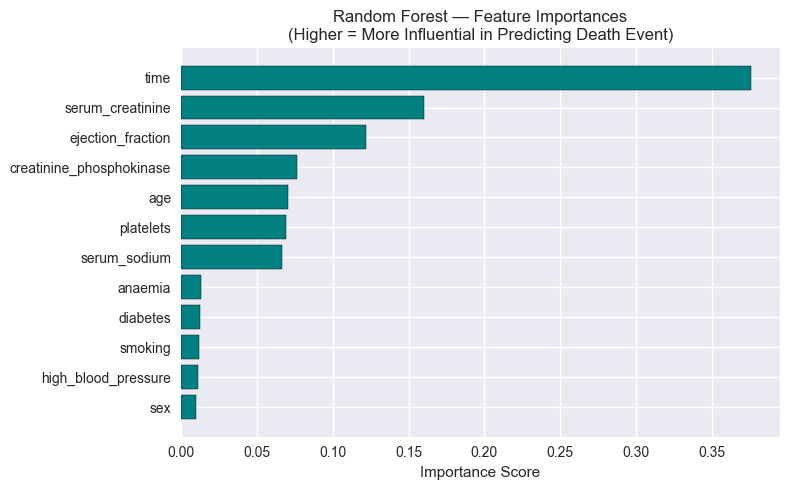


Top 3 most important clinical features:
          Feature  Importance
             time    0.376176
 serum_creatinine    0.160101
ejection_fraction    0.122045


In [9]:
feature_names = X_train.columns.tolist()
importances   = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Feature Importances (sorted by magnitude):')
print(feat_df.to_string(index=False))

# Bar chart — same style as LR coefficient chart
plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='teal', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importances\n(Higher = More Influential in Predicting Death Event)')
plt.tight_layout()
plt.show()

print('\nTop 3 most important clinical features:')
print(feat_df.head(3).to_string(index=False))